In [82]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [83]:
csv_path=Path(r"C:\Users\ASUS\OneDrive\Desktop\neyron_sebekeler\ai.ss.ipynb\Mall_Customers.csv")
df=pd.read_csv(csv_path)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [84]:
df.shape

(200, 5)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [86]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [87]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [88]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

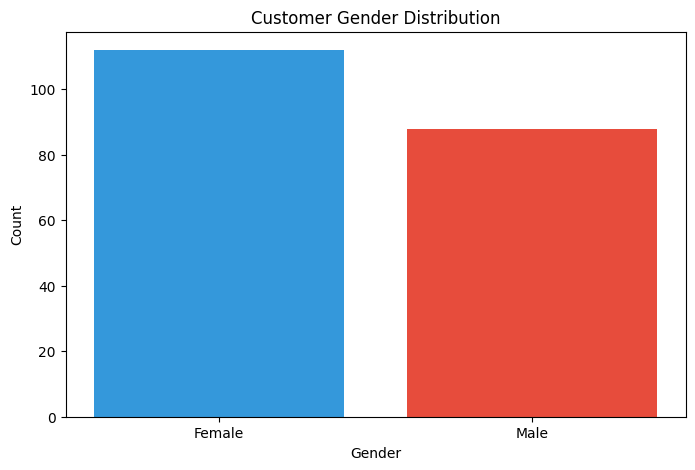

In [89]:
plt.figure(figsize=(8,5))

gender_counts = df["Gender"].value_counts()

plt.bar(gender_counts.index, gender_counts.values , color=["#3498db","#e74c3c"])

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

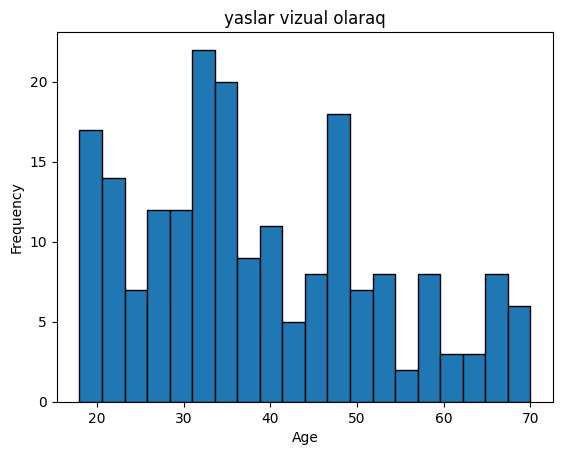

In [90]:
plt.Figure(figsize=(10,5))
plt.hist(df["Age"] , bins=20 , edgecolor="black")
plt.title("yaslar vizual olaraq")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

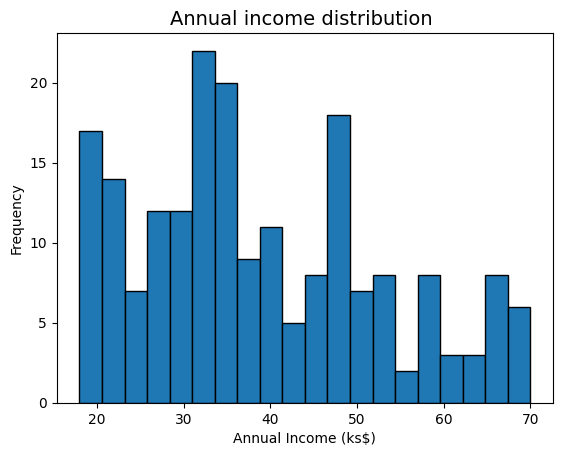

In [91]:
plt.Figure(figsize=(10,5))
plt.hist(df["Age"] , bins=20 , edgecolor="black" ,)
plt.title("Annual income distribution " , fontsize=14)
plt.xlabel("Annual Income (ks$)")
plt.ylabel("Frequency")

plt.show()

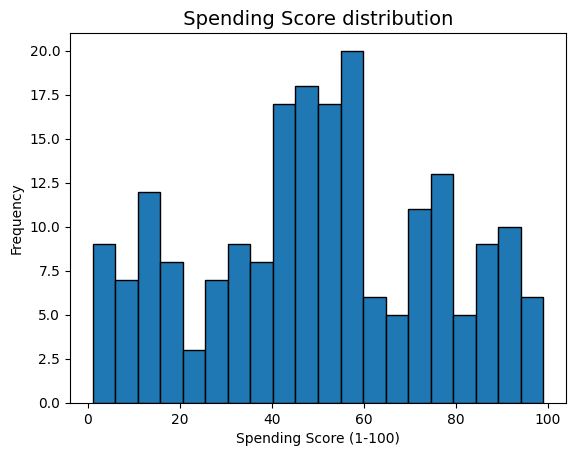

In [92]:
plt.Figure(figsize=(10,5))
plt.hist(df["Spending Score (1-100)"] , bins=20 , edgecolor="black" ,)
plt.title(" Spending Score distribution " , fontsize=14)
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Frequency")

plt.show()

In [93]:
x=df.iloc[:, [3,4]].values
x


array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [94]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [95]:
from sklearn.cluster import KMeans

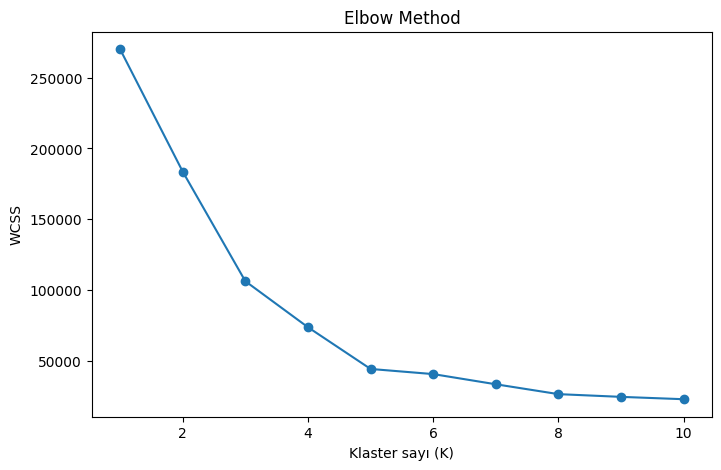

In [96]:
k = []

# 1-dən 10 qeder
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)  
    k.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), k, marker='o')

plt.title("Elbow Method")
plt.xlabel("Klaster sayı (K)")
plt.ylabel("WCSS")

plt.show()

train

In [97]:
kmeans=KMeans(n_clusters=5,init="k-means++", random_state=122)
y=kmeans.fit_predict(x)

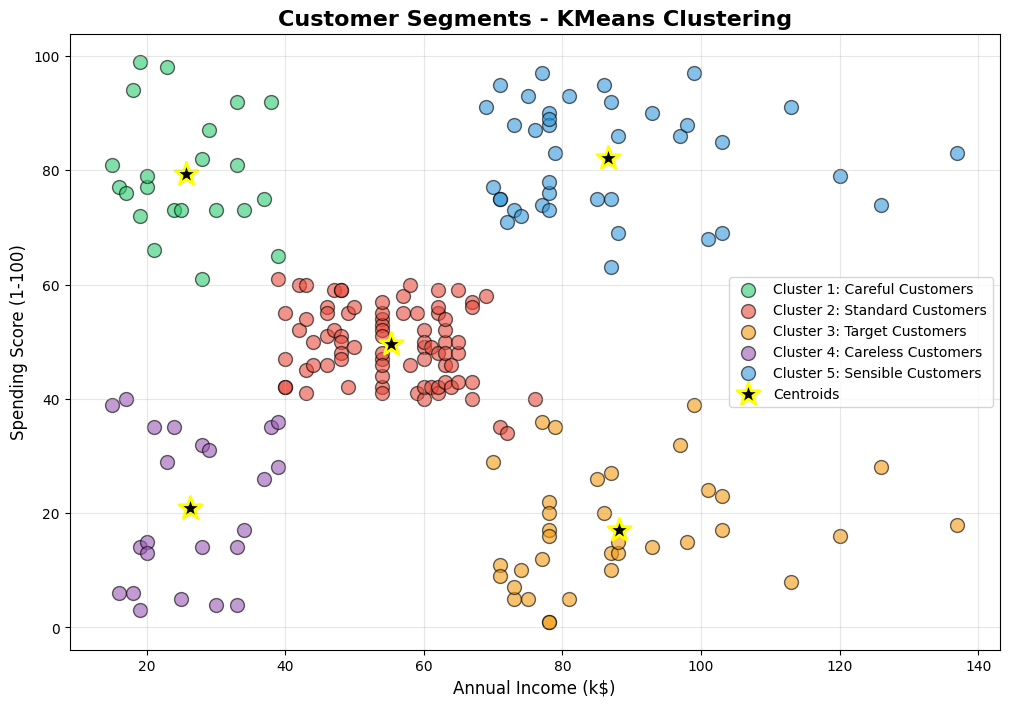

In [98]:
plt.figure(figsize=(12, 8))

colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db']
clusters_names = [
    'Careful Customers',
    'Standard Customers',
    'Target Customers',
    'Careless Customers',
    'Sensible Customers'
]

for i in range(5):
    plt.scatter(
        x[y == i, 0],
        x[y == i, 1],
        s=100,
        c=colors[i],
        label=f'Cluster {i+1}: {clusters_names[i]}',
        alpha=0.6,
        edgecolors='black'
    )

# Centroidler
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='black',
    marker='*',
    label='Centroids',
    edgecolors='yellow',
    linewidths=2
)

plt.title('Customer Segments - KMeans Clustering', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

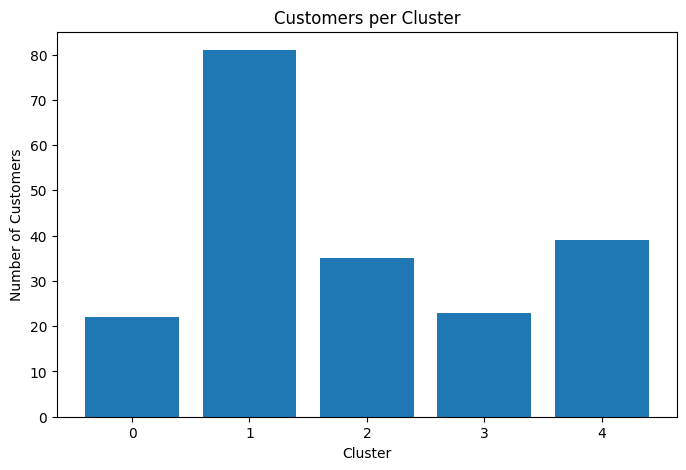

In [99]:
cluster_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(cluster_counts.index, cluster_counts.values)

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [100]:
df["Cluster"]=y

yukleme

In [101]:
import joblib

joblib.dump(kmeans, "customers_model.pkl")
print("model saved")

model saved


In [102]:
model = joblib.load("customers_model.pkl")

In [103]:
model.predict(x)

array([3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 1,
       3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 2, 4, 1, 4, 2, 4, 2, 4,
       1, 4, 2, 4, 2, 4, 2, 4, 2, 4, 1, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4], dtype=int32)